# Jackson 2.11: Line Charge Outside a Conducting Cylinder

This notebook develops the solution of Jackson 2.11 for a line charge placed outside a conducting cylinder. The solution in the PDF from `Jackson_2_11_Homework_Solution.pdf` is reproduced here with a more explicit physical interpretation and a few numerical checks.

A line charge with linear density $\tau$ is located parallel to the $z$ axis at a distance $R>b$ from the axis of a conducting cylinder of radius $b$. The cylinder is held at a fixed potential and the potential is chosen to vanish at infinity.

We will determine:

1. the image charge magnitude and position,
2. the exact potential in polar coordinates,
3. the asymptotic form far from the cylinder,
4. the induced surface-charge density,
5. and the force per unit length on the physical line charge.


## Geometry and the Image Construction

Take cylindrical-polar coordinates $(\rho,\phi,z)$ centered on the cylinder axis. The physical line charge sits on the positive $x$ axis at $\rho=R$ and $\phi=0$.

For a line charge in two dimensions, the potential has the logarithmic form

$$
\Phi_{\rm line}(r)=\frac{\tau}{4\pi\varepsilon_0}\ln\left(\frac{B^2}{r^2}\right),
$$

where $r$ is the distance to the line charge and $B$ is an arbitrary constant.

We try the same strategy as the point-charge/sphere method of images: place one image line charge inside the cylinder at radius $R'$ on the same axis. The total potential becomes

$$
\Phi(\rho,\phi)=\frac{\tau}{4\pi\varepsilon_0}\ln\left(\frac{B^2}{r_1^2}\right)+\frac{\tau'}{4\pi\varepsilon_0}\ln\left(\frac{B^2}{r_2^2}\right),
$$

with

$$
r_1^2=\rho^2+R^2-2\rho R\cos\phi,
\qquad
r_2^2=\rho^2+R'^2-2\rho R'\cos\phi.
$$

The condition $\Phi\to 0$ as $\rho\to\infty$ forces the total line charge to vanish, so

$$
\tau'=-\tau.
$$

The remaining boundary condition is that the cylinder surface $\rho=b$ be an equipotential. The cleanest way to see the answer is to demand that the ratio $r_2^2/r_1^2$ be independent of $\phi$ when $\rho=b$. Choosing

$$
R'=\frac{b^2}{R}
$$

gives

$$
b^2+R'^2-2bR'\cos\phi
=\frac{b^2}{R^2}\left(b^2+R^2-2bR\cos\phi\right),
$$

so the ratio is constant on the boundary. That is the inversion property that makes the image method work for the cylinder.


## Exact Potential and Cylinder Voltage

With $\tau'=-\tau$ and $R'=b^2/R$, the potential outside the cylinder is

$$
\Phi(\rho,\phi)=\frac{\tau}{4\pi\varepsilon_0}
\ln\left(\frac{\rho^2+R'^2-2\rho R'\cos\phi}{\rho^2+R^2-2\rho R\cos\phi}\right),
\qquad
R'=\frac{b^2}{R}.
$$

On the cylinder surface $\rho=b$, this becomes a constant:

$$
\Phi(b,\phi)=\frac{\tau}{4\pi\varepsilon_0}\ln\left(\frac{b^2}{R^2}\right)
=\frac{\tau}{2\pi\varepsilon_0}\ln\left(\frac{b}{R}\right).
$$

So the cylinder is indeed an equipotential. Since $R>b$, the logarithm is negative, so the cylinder potential is negative relative to infinity.

Far from both the line charge and the cylinder, the leading asymptotic term is

$$
\Phi_{\rm asym}(\rho,\phi)=\frac{\tau}{2\pi\varepsilon_0}
\frac{R^2-b^2}{\rho R}\cos\phi.
$$

This is the potential of a two-dimensional dipole. The real line charge plus the induced charge on the conductor form a neutral system, so the monopole term vanishes and the first surviving far-field term is dipolar.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
eps0 = 1.0
tau = 1.0
b = 1.0
R = 2.4
R_image = b**2 / R


def image_radius(R, b):
    return b**2 / R


def cylinder_voltage(R, b, tau=1.0, eps0=1.0):
    return (tau / (2.0 * np.pi * eps0)) * np.log(b / R)


def potential_cylinder(rho, phi, R, b, tau=1.0, eps0=1.0):
    Rp = image_radius(R, b)
    r1_sq = rho**2 + R**2 - 2.0 * rho * R * np.cos(phi)
    r2_sq = rho**2 + Rp**2 - 2.0 * rho * Rp * np.cos(phi)
    return (tau / (4.0 * np.pi * eps0)) * np.log(r2_sq / r1_sq)


def potential_cartesian(x, y, R, b, tau=1.0, eps0=1.0):
    rho = np.hypot(x, y)
    phi = np.arctan2(y, x)
    return potential_cylinder(rho, phi, R, b, tau=tau, eps0=eps0)


def sigma_phi(phi, R, b, tau=1.0):
    alpha = R / b
    return (tau / (2.0 * np.pi * b)) * (1.0 - alpha**2) / (1.0 + alpha**2 - 2.0 * alpha * np.cos(phi))


def sigma_normalized(phi, R_over_b):
    alpha = R_over_b
    return (1.0 - alpha**2) / (1.0 + alpha**2 - 2.0 * alpha * np.cos(phi))


def phi_asymptotic(rho, phi, R, b, tau=1.0, eps0=1.0):
    return (tau / (2.0 * np.pi * eps0)) * ((R**2 - b**2) / (rho * R)) * np.cos(phi)


def force_per_length(R, b, tau=1.0, eps0=1.0):
    return -(tau**2 * R) / (2.0 * np.pi * eps0 * (R**2 - b**2))


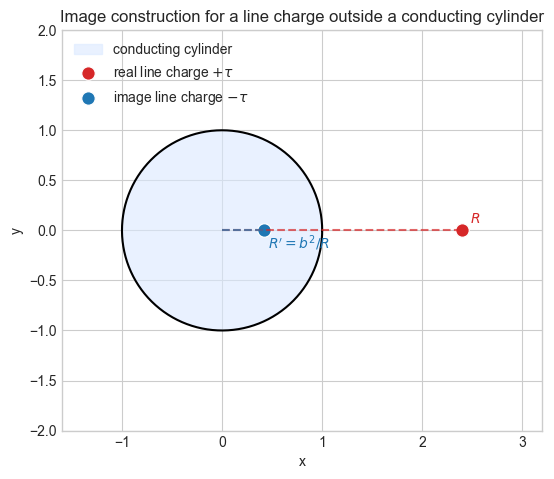

In [3]:
theta = np.linspace(0.0, 2.0 * np.pi, 600)
x_circle = b * np.cos(theta)
y_circle = b * np.sin(theta)

fig, ax = plt.subplots(figsize=(6.2, 6.2))
ax.fill(x_circle, y_circle, color="#dbe9ff", alpha=0.6, label="conducting cylinder")
ax.plot(x_circle, y_circle, color="black", lw=1.5)
ax.scatter([R], [0.0], s=95, color="tab:red", edgecolor="white", linewidth=0.9, label=r"real line charge $+\tau$")
ax.scatter([R_image], [0.0], s=95, color="tab:blue", edgecolor="white", linewidth=0.9, label=r"image line charge $-\tau$")
ax.plot([0.0, R], [0.0, 0.0], ls="--", color="tab:red", alpha=0.7)
ax.plot([0.0, R_image], [0.0, 0.0], ls="--", color="tab:blue", alpha=0.7)
ax.text(R + 0.08, 0.08, r"$R$", color="tab:red")
ax.text(R_image + 0.04, -0.18, r"$R'=b^2/R$", color="tab:blue")
ax.set_aspect("equal")
ax.set_xlim(-1.6, 3.2)
ax.set_ylim(-2.0, 2.0)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Image construction for a line charge outside a conducting cylinder")
ax.legend(loc="upper left")
plt.show()


## Boundary Check

A good sanity test is that the potential on the cylinder be constant and that its angular derivative vanish there. Since

$$
E_\phi=-\frac{1}{\rho}\frac{\partial \Phi}{\partial \phi},
$$

a constant boundary potential automatically means zero tangential field.


In [4]:
phi_samples = np.linspace(0.0, 2.0 * np.pi, 2000, endpoint=False)
phi_boundary = potential_cylinder(b, phi_samples, R, b, tau=tau, eps0=eps0)
V_exact = cylinder_voltage(R, b, tau=tau, eps0=eps0)
dphi = phi_samples[1] - phi_samples[0]
e_tangent = -(1.0 / b) * np.gradient(phi_boundary, dphi, edge_order=2)

print(f"R' = b^2/R = {R_image:.6f}")
print(f"tau' = {-tau:+.6f}")
print(f"Cylinder potential V = {V_exact:+.6f}")
print(f"max |Phi(b,phi) - V| = {np.max(np.abs(phi_boundary - V_exact)):.3e}")
print(f"max |E_phi(b,phi)|    = {np.max(np.abs(e_tangent)):.3e}")


R' = b^2/R = 0.416667
tau' = -1.000000
Cylinder potential V = -0.139335
max |Phi(b,phi) - V| = 2.776e-17
max |E_phi(b,phi)|    = 1.066e-14


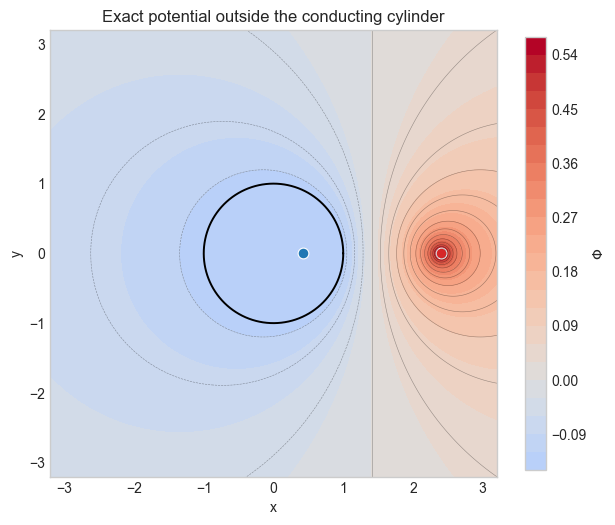

In [5]:
x = np.linspace(-3.4, 3.4, 320)
y = np.linspace(-3.4, 3.4, 320)
X, Y = np.meshgrid(x, y, indexing="xy")
rho_grid = np.hypot(X, Y)
phi_grid = np.arctan2(Y, X)

Phi_ext = potential_cylinder(rho_grid, phi_grid, R, b, tau=tau, eps0=eps0)
Phi_plot = np.where(rho_grid >= b, Phi_ext, V_exact)

real_core = np.hypot(X - R, Y) < 0.06
image_core = np.hypot(X - R_image, Y) < 0.05
Phi_plot = np.where(real_core | image_core, np.nan, Phi_plot)

vmax = np.nanmax(np.abs(Phi_plot))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, ax = plt.subplots(figsize=(7.2, 6.4))
contf = ax.contourf(X, Y, Phi_plot, levels=24, cmap="coolwarm", norm=norm)
ax.contour(X, Y, Phi_plot, levels=18, colors="black", linewidths=0.42, alpha=0.35)
ax.plot(x_circle, y_circle, color="black", lw=1.4)
ax.scatter([R], [0.0], s=60, color="tab:red", edgecolor="white", linewidth=0.8)
ax.scatter([R_image], [0.0], s=60, color="tab:blue", edgecolor="white", linewidth=0.8)
ax.set_aspect("equal")
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-3.2, 3.2)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Exact potential outside the conducting cylinder")
fig.colorbar(contf, ax=ax, shrink=0.88, label=r"$\Phi$")
plt.show()


## Surface Charge Density

The normal-field discontinuity on a conductor gives

$$
\sigma=-\varepsilon_0\left.\frac{\partial \Phi}{\partial \rho}\right|_{\rho=b}.
$$

Substituting the exact potential yields

$$
\sigma(\phi)=\frac{\tau}{2\pi b}
\frac{1-(R/b)^2}{1+(R/b)^2-2(R/b)\cos\phi}.
$$

The numerator is negative because $R>b$, so the induced charge density is everywhere negative, as expected for a positive external line charge.


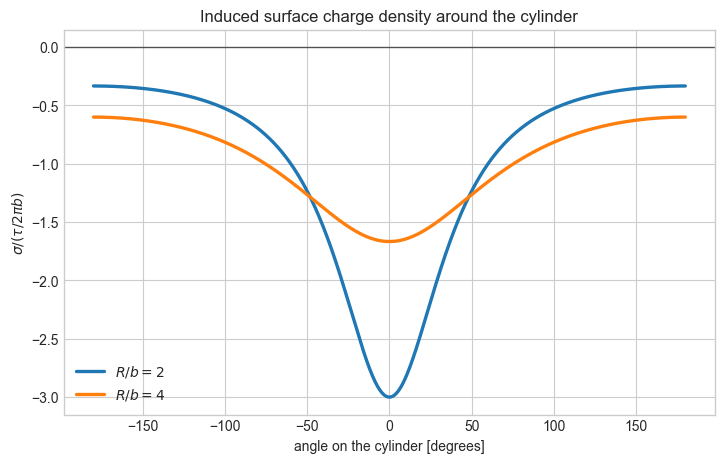

In [6]:
phi_deg = np.linspace(-180.0, 180.0, 1600)
phi_rad = np.deg2rad(phi_deg)

fig, ax = plt.subplots(figsize=(8.4, 5.0))
for alpha, color in [(2.0, 'tab:blue'), (4.0, 'tab:orange')]:
    ax.plot(phi_deg, sigma_normalized(phi_rad, alpha), lw=2.4, color=color, label=fr"$R/b={alpha:.0f}$")
ax.axhline(0.0, color="black", lw=1.0, alpha=0.6)
ax.set_xlabel("angle on the cylinder [degrees]")
ax.set_ylabel(r"$\sigma / (\tau / 2\pi b)$")
ax.set_title("Induced surface charge density around the cylinder")
ax.legend()
plt.show()


In [7]:
phi_int = np.linspace(0.0, 2.0 * np.pi, 20000, endpoint=False)
sigma_total = np.trapezoid(sigma_phi(phi_int, R, b, tau=tau) * b, phi_int)
print(f"Total induced charge per unit length on the cylinder = {sigma_total:+.6f}")


Total induced charge per unit length on the cylinder = -0.999879


## Far-Field Comparison

Because the real line charge and the induced conductor charge sum to zero, the far field cannot be monopolar. The exact potential should approach the dipole-like asymptotic form

$$
\Phi_{\rm asym}(\rho,\phi)=\frac{\tau}{2\pi\varepsilon_0}
\frac{R^2-b^2}{\rho R}\cos\phi.
$$

We compare the two along a fixed ray.


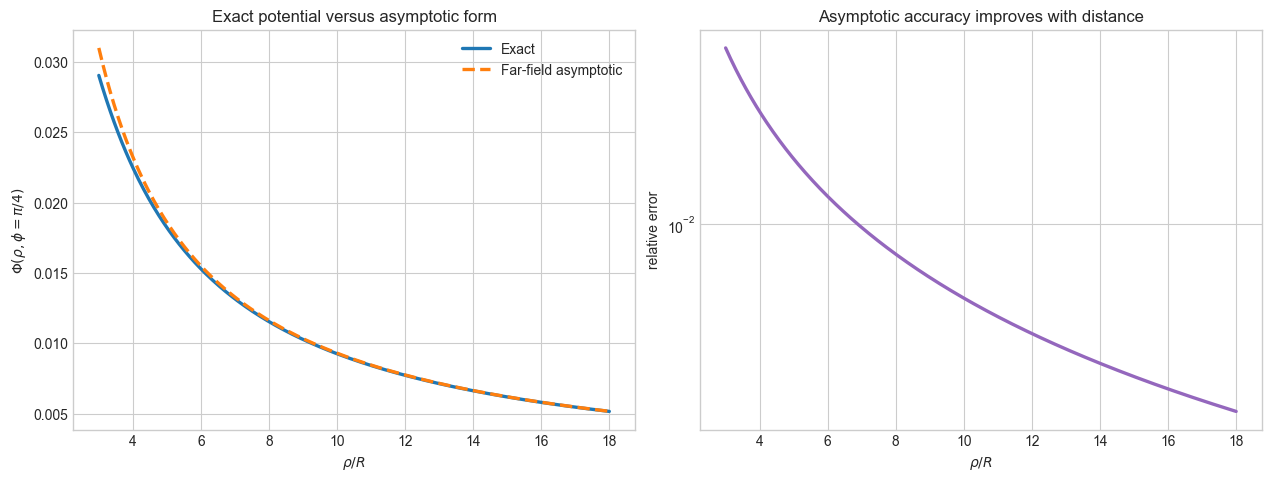

max relative error for rho >= 6R: 1.345e-02


In [8]:
phi_ray = np.pi / 4.0
rho_values = np.linspace(3.0 * R, 18.0 * R, 400)
phi_exact = potential_cylinder(rho_values, phi_ray, R, b, tau=tau, eps0=eps0)
phi_far = phi_asymptotic(rho_values, phi_ray, R, b, tau=tau, eps0=eps0)
relative_error = np.abs(phi_far - phi_exact) / np.maximum(np.abs(phi_exact), 1.0e-14)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.7), constrained_layout=True)
axes[0].plot(rho_values / R, phi_exact, lw=2.4, label="Exact")
axes[0].plot(rho_values / R, phi_far, lw=2.4, ls="--", label="Far-field asymptotic")
axes[0].set_xlabel(r"$\rho/R$")
axes[0].set_ylabel(r"$\Phi(\rho,\phi=\pi/4)$")
axes[0].set_title("Exact potential versus asymptotic form")
axes[0].legend()

axes[1].semilogy(rho_values / R, relative_error, color="tab:purple", lw=2.4)
axes[1].set_xlabel(r"$\rho/R$")
axes[1].set_ylabel("relative error")
axes[1].set_title("Asymptotic accuracy improves with distance")

plt.show()
print(f"max relative error for rho >= 6R: {relative_error[rho_values >= 6.0 * R].max():.3e}")


## Force Per Unit Length

The physical line charge feels only the field of the image line charge. Since the image carries charge $-\tau$ and sits at radius $R'=b^2/R$, the separation between the two lines is

$$
d=R-R'=R-\frac{b^2}{R}=\frac{R^2-b^2}{R}.
$$

The field at the physical line charge due to the image is therefore

$$
E=\frac{-\tau}{2\pi\varepsilon_0 d}\,\hat{\rho},
$$

so the force per unit length is

$$
\frac{\mathbf{F}}{L}=-\frac{\tau^2 R}{2\pi\varepsilon_0(R^2-b^2)}\,\hat{\rho}.
$$

The sign shows that the force is attractive: the line charge is pulled inward toward the cylinder.


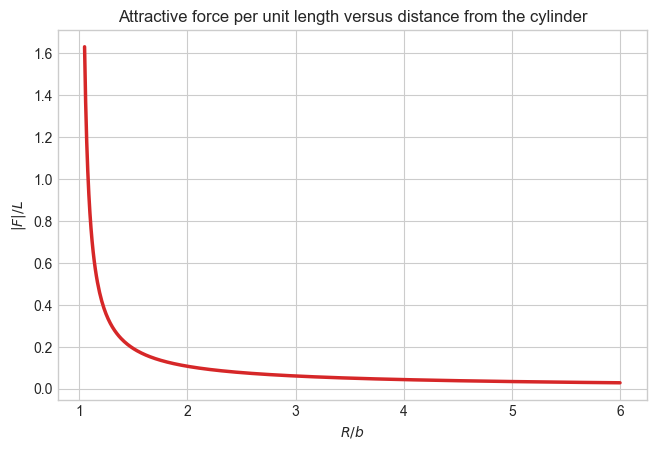

Force per unit length for R/b = 2.40: -0.080246


In [9]:
alpha_values = np.linspace(1.05, 6.0, 500)
force_mag = -force_per_length(alpha_values * b, b, tau=tau, eps0=eps0)

fig, ax = plt.subplots(figsize=(7.6, 4.8))
ax.plot(alpha_values, force_mag, lw=2.5, color="tab:red")
ax.set_xlabel(r"$R/b$")
ax.set_ylabel(r"$|F|/L$")
ax.set_title("Attractive force per unit length versus distance from the cylinder")
plt.show()

print(f"Force per unit length for R/b = {R/b:.2f}: {force_per_length(R, b, tau=tau, eps0=eps0):+.6f}")


## Takeaway

The whole problem works because inversion in the circle maps the outside source at $R$ to the inside image at $b^2/R$. Together with the requirement that the potential vanish at infinity, that fixes the image charge to be $-\tau$. The conductor surface then becomes an exact equipotential, the induced charge density follows directly from the normal derivative, and the far field reduces to a dipole because the net charge of the full system is zero.
